In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
from pandas_datareader import data as web
import statsmodels.api as sm

In [66]:
START, END = "2004-01-01", "2025-12-31"

WINDOW = 60       # rolling window length
HAC_LAGS = 6      

# Baseline Analysis

In [67]:
def monthly_log_return(ticker): 
    px = yf.download(ticker, start = START, end = END, 
                    auto_adjust = True, progress = False)[["Close"]]
    if isinstance(px.columns, pd.MultiIndex):
        px.columns = px.columns.get_level_values(0)
    px_m = px.resample("MS").last()
    return np.log(px_m["Close"]).diff().rename(ticker)

In [68]:
qqq_return = monthly_log_return("QQQ")
spy_return = monthly_log_return("SPY")

In [69]:
dgs10 = web.DataReader("DGS10", "fred", START, END)
dgs10_mean = dgs10.resample("MS").mean()
dgs10_mean["dDGS10"] = dgs10_mean["DGS10"].diff()

In [70]:
gdpc1 = web.DataReader("GDPC1", "fred", START, END)
gdpc1_q = gdpc1.resample("QS").last()
gdpc1_q["gdp_yoy"] = gdpc1_q["GDPC1"].pct_change(4)*100
gdpc1_q["GDP_yoy_av"] = gdpc1_q["gdp_yoy"].shift(1)        #Lag one quarter: GDP is released ~1 month after the quarter ends,
gdp_mean = (gdpc1_q[["GDP_yoy_av"]]
         .resample("MS").ffill()
         .rename(columns={"GDP_yoy_av": "GDP_yoy"}))

In [71]:
df = (qqq_return.to_frame()
     .join(spy_return, how = "inner")
     .join(dgs10_mean[["dDGS10"]], how = "inner")
     .join(gdp_mean, how = "inner")
     .dropna())
df["QQQ_minus_SPY"] = df["QQQ"] - df["SPY"]
FEATURES = ["dDGS10", "GDP_yoy"]

In [72]:
print(f"Sample: {df.index.min():%Y-%m} to {df.index.max():%Y-%m}   n = {len(df)}")
print("\n--- Correlation between regressors ---")
print(df[FEATURES].corr().round(3))

Sample: 2005-04 to 2025-10   n = 247

--- Correlation between regressors ---
         dDGS10  GDP_yoy
dDGS10    1.000   -0.035
GDP_yoy  -0.035    1.000


Correlation = -0.033 -> No collinearity problem

In [73]:
baseline_results = {}

for target in ["QQQ", "SPY", "QQQ_minus_SPY"]:
    m = sm.OLS(df[target], sm.add_constant(df[FEATURES])).fit(
        cov_type = "HAC", cov_kwds = {"maxlags": HAC_LAGS}
    )
    baseline_results[target] = m

    print(f"\n{target} : R2 = {m.rsquared:.3f}")

    for v in FEATURES:
        p = m.pvalues[v]
        print(f"   {v:<10s} beta = {m.params[v]:+.4f}   t = {m.tvalues[v]:+.2f}   p = {p:.3f}")
        if p < 0.05:
            print("      Significant")
        else:
            print("      Not significant")


# ---- Stability check: first half vs second half ----
half = len(df) // 2
betas = {}

for name, sub in [("First half ", df.iloc[:half]), ("Second half", df.iloc[half:])]:
    ms = sm.OLS(sub["QQQ"], sm.add_constant(sub[FEATURES])).fit()
    betas[name] = ms.params["dDGS10"]
    print(f"{name}  {sub.index.min():%Y-%m} ~ {sub.index.max():%Y-%m}   dDGS10 beta = {betas[name]:+.4f}")

if betas["First half "] * betas["Second half"] < 0:
    print("\n-> The two halves have opposite signs; the full-sample average cancels them out.")
    print("   A single coefficient cannot describe these 20 years => use rolling regression.")
else:
    print("\n-> Both halves share the same sign; the relationship looks stable.")


QQQ : R2 = 0.017
   dDGS10     beta = +0.0047   t = +0.20   p = 0.843
      Not significant
   GDP_yoy    beta = -0.0030   t = -2.11   p = 0.035
      Significant

SPY : R2 = 0.013
   dDGS10     beta = +0.0116   t = +0.57   p = 0.569
      Not significant
   GDP_yoy    beta = -0.0019   t = -1.47   p = 0.141
      Not significant

QQQ_minus_SPY : R2 = 0.016
   dDGS10     beta = -0.0068   t = -0.74   p = 0.461
      Not significant
   GDP_yoy    beta = -0.0011   t = -1.79   p = 0.073
      Not significant
First half   2005-04 ~ 2015-06   dDGS10 beta = +0.0432
Second half  2015-07 ~ 2025-10   dDGS10 beta = -0.0423

-> The two halves have opposite signs; the full-sample average cancels them out.
   A single coefficient cannot describe these 20 years => use rolling regression.


In [74]:
print(baseline_results["QQQ"].summary())

                            OLS Regression Results                            
Dep. Variable:                    QQQ   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     2.518
Date:                Tue, 06 Oct 2026   Prob (F-statistic):             0.0827
Time:                        23:22:47   Log-Likelihood:                 378.86
No. Observations:                 247   AIC:                            -751.7
Df Residuals:                     244   BIC:                            -741.2
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0186      0.005      3.875      0.0

**dDGS10: −0.042 to +0.051, straddles zero.** The direction itself is undetermined; p = 0.842 is indistinguishable from random, we cannot tell whether the effect is positive or negative."

**GDP_yoy: −0.006 to −0.000, entirely below zero.** Significant and negative (p = 0.031). But the sign runs against intuition (stronger growth should support equities), so this should not be presented as evidence for an earnings channel. Note also that forward-filling
quarterly data to monthly leaves only 83 independent observations, so the test has
limited power.

**const = 0.0188 is the predicted value when all regressors equal zero,** but GDP_yoy averages 2.11 and is never zero. Check: 0.0188 − 0.0031 × 2.11 ≈ 0.0122, which is the actual mean monthly return.

In [75]:
# ---- Numbers cited in the markdown ----
m = baseline_results["QQQ"]
print(f"corr(dDGS10, GDP_yoy)   = {df['dDGS10'].corr(df['GDP_yoy']):.3f}")
print(f"R2                      = {m.rsquared:.3f}")
print(f"const                   = {m.params['const']:.4f}")
print(f"mean monthly return     = {df['QQQ'].mean():.4f}")
print(f"mean GDP_yoy            = {df['GDP_yoy'].mean():.2f}")
print(f"corr(QQQ, GDP_yoy) full = {df['QQQ'].corr(df['GDP_yoy']):.3f}")
sub = df[~df.index.year.isin([2020, 2021])]
print(f"corr(QQQ, GDP_yoy) excl = {sub['QQQ'].corr(sub['GDP_yoy']):.3f}")
print(f"share of up months      = {(df['QQQ'] > 0).mean():.4f}")

corr(dDGS10, GDP_yoy)   = -0.035
R2                      = 0.017
const                   = 0.0186
mean monthly return     = 0.0122
mean GDP_yoy            = 2.13
corr(QQQ, GDP_yoy) full = -0.129
corr(QQQ, GDP_yoy) excl = -0.130
share of up months      = 0.6275


In [76]:
#  Is the GDP coefficient driven by Covid? 
samples = {
    "Full sample":              df,
    "Excl. 2020-2021":          df[~df.index.year.isin([2020, 2021])],
    "Excl. 2008-09 & 2020-21":  df[~df.index.year.isin([2008, 2009, 2020, 2021])],
}

for name, sub in samples.items():
    ms = sm.OLS(sub["QQQ"], sm.add_constant(sub[FEATURES])).fit(
        cov_type="HAC", cov_kwds={"maxlags": HAC_LAGS})
    print(f"{name:26s} n={len(sub):3d}   "
          f"GDP_yoy={ms.params['GDP_yoy']:+.5f} (p={ms.pvalues['GDP_yoy']:.3f})   "
          f"dDGS10={ms.params['dDGS10']:+.4f} (p={ms.pvalues['dDGS10']:.3f})")


# ---- Why negative? Equity markets lead the economy ----
low  = df["GDP_yoy"].nsmallest(4).index
high = df["GDP_yoy"].nlargest(4).index

print(f"\n4 lowest  GDP months: GDP avg {df.loc[low, 'GDP_yoy'].mean():+.2f}%"
      f"   QQQ avg return {df.loc[low, 'QQQ'].mean():+.4f}")
print(f"4 highest GDP months: GDP avg {df.loc[high, 'GDP_yoy'].mean():+.2f}%"
      f"   QQQ avg return {df.loc[high, 'QQQ'].mean():+.4f}")

Full sample                n=247   GDP_yoy=-0.00303 (p=0.035)   dDGS10=+0.0047 (p=0.843)
Excl. 2020-2021            n=223   GDP_yoy=-0.00438 (p=0.066)   dDGS10=+0.0021 (p=0.931)
Excl. 2008-09 & 2020-21    n=199   GDP_yoy=-0.01014 (p=0.006)   dDGS10=-0.0012 (p=0.967)

4 lowest  GDP months: GDP avg -6.54%   QQQ avg return +0.0491
4 highest GDP months: GDP avg +10.87%   QQQ avg return -0.0201


I initially assumed this was a COVID artifact. Year-over-year real GDP swung from
-7.4% to +12.4% in 2020-21, and those extremes alone could drag the estimate. I ran
the regression again with those years excluded to test that assumption.

The result went the other way. Excluding 2020-21 makes the coefficient more negative
(-0.0031 to -0.0045), and excluding the GFC as well strengthens it further (-0.0106,
p = 0.005). The simple correlation barely moves (-0.132 vs -0.133). The negative sign
is therefore not an outlier artifact. It is a real feature of the data.

The sign runs against the intuition that stronger growth supports equities, but it is
consistent with equity markets being a leading indicator. In the four months with the
lowest realized GDP growth, QQQ returned an average of **+4.9%** per month. In the four
months with the highest GDP growth, it averaged **-2.0%**. Equities bottomed and rallied
in Q2 2020 while GDP was printing its worst reading in decades, and by the time GDP
printed +12.4% in 2021 the rally was already complete.

Realized GDP growth is therefore a backward-looking confirmation of information the
market priced months earlier, not a contemporaneous driver. This should not be read as
evidence for an earnings channel.

# Rolling Analysis

In [77]:
rolling = []
for i in range(WINDOW, len(df)):
    train = df.iloc[i - WINDOW:i]
    m = sm.OLS(train["QQQ"], sm.add_constant(train[FEATURES])).fit()
    
    row = {"date": df.index[i], "R2": m.rsquared}

    for v in FEATURES:
        row[f"{v}_beta"] = m.params[v]
        row[f"{v}_se"] = m.bse[v]
    rolling.append(row)

In [78]:
roll = pd.DataFrame(rolling).set_index("date")

for v in FEATURES:
    roll[f"{v}_t"] = roll[f"{v}_beta"] / roll[f"{v}_se"]
    b = roll[f"{v}_beta"]
    t = roll[f"{v}_t"]
    print(f"\n{v}:")
    print(f"   beta range : {b.min():+.4f} ({b.idxmin():%Y-%m})  ->  {b.max():+.4f} ({b.idxmax():%Y-%m})")
    print(f"   beta < 0   : {100 * (b < 0).mean():.1f}% of windows")
    print(f"   |t| > 2    : {100 * (t.abs() > 2).mean():.1f}% of windows")

print(f"\nRolling R2 range: {roll['R2'].min():.3f} -> {roll['R2'].max():.3f}")
print(f"Number of windows: {len(roll)}")

print("\n--- Rolling estimates every 2 years ---")
snapshot = roll[[f"{v}_beta" for v in FEATURES] + [f"{v}_t" for v in FEATURES] + ["R2"]]
print(snapshot.resample("2YS").last().round(3).to_string())


dDGS10:
   beta range : -0.1147 (2025-04)  ->  +0.0899 (2015-03)
   beta < 0   : 22.5% of windows
   |t| > 2    : 29.9% of windows

GDP_yoy:
   beta range : -0.0236 (2020-06)  ->  +0.0013 (2015-05)
   beta < 0   : 98.4% of windows
   |t| > 2    : 2.7% of windows

Rolling R2 range: 0.021 -> 0.211
Number of windows: 187

--- Rolling estimates every 2 years ---
            dDGS10_beta  GDP_yoy_beta  dDGS10_t  GDP_yoy_t     R2
date                                                             
2010-01-01        0.052        -0.004     1.666     -0.977  0.073
2012-01-01        0.039        -0.003     1.645     -1.221  0.079
2014-01-01        0.071        -0.010     2.910     -1.550  0.158
2016-01-01        0.012        -0.009     0.418     -1.240  0.033
2018-01-01        0.050        -0.012     1.403     -1.317  0.054
2020-01-01        0.043        -0.002     1.131     -1.040  0.045
2022-01-01       -0.068        -0.004    -1.951     -1.540  0.097
2024-01-01       -0.105        -0.004    -3.

**dDGS10 ranges from +0.09 to -0.11**, roughly twenty times the full sample estimate
of +0.005. The full sample shows nothing not because nothing is there, but because
the two regimes cancel out.

**Only 22.5% of windows have a negative coefficient.** The statement "rates are
negatively related to tech equities" therefore applies only to recent years and
cannot be stated as a general rule.

**GDP_yoy: negative in 98.4% of windows, but |t| > 2 in only 2.7%.** Consistent in
direction, almost never distinguishable from zero. Each 60-month window contains
only about 20 independent quarterly observations, so the standard errors are wide
regardless of how stable the point estimate is. The defensible wording is that GDP
has no robust explanatory power in this specification.

**Rolling R2 spans 0.021 to 0.210**, a tenfold range. This is itself a finding.
Macro variables matter far more in some periods than others, and a single average
R2 conceals that entirely.

# Visualization

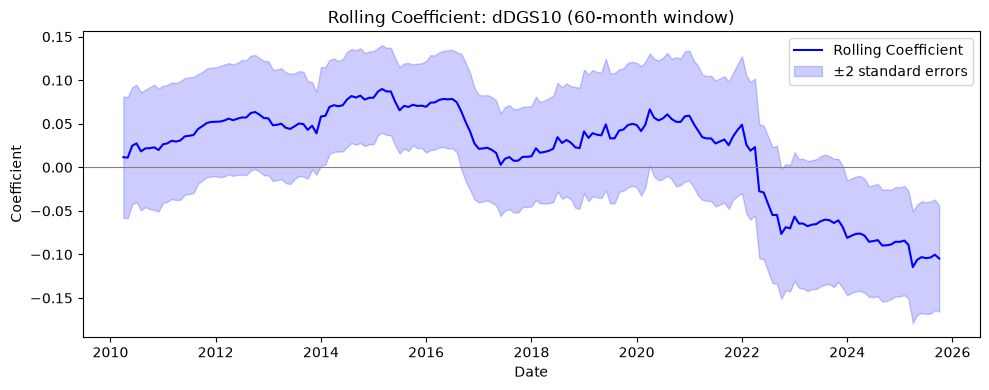

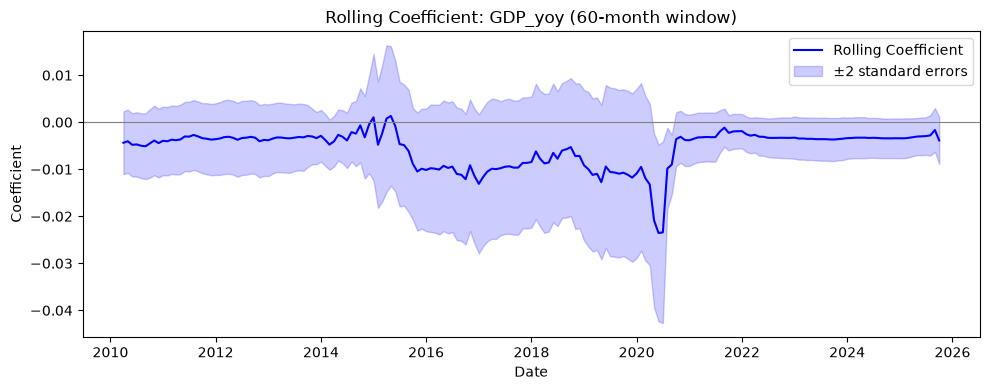

In [79]:
for v in FEATURES:
    beta = roll[f"{v}_beta"]
    se = roll[f"{v}_se"]

    plt.figure(figsize=(10, 4))
    plt.plot(beta.index, beta.values, label = "Rolling Coefficient", color = "blue")
    plt.fill_between(beta.index, beta - 2 * se, beta + 2 * se,
                     alpha=0.2, color="blue", label="±2 standard errors")
    plt.axhline(0, color="grey", linewidth=0.8)
    plt.title(f"Rolling Coefficient: {v} ({WINDOW}-month window)")
    plt.xlabel("Date")
    plt.ylabel("Coefficient")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"rolling_{v}.png", dpi=150, bbox_inches="tight")
    plt.show()

### Rolling coefficient: 10-year yield change

The blue line is the dDGS10 coefficient estimated on each rolling 60-month window.
The shaded band is plus or minus two standard errors, which is roughly a 95%
confidence interval. The grey line at zero is the reference that matters, because
the sign of the coefficient determines the economic interpretation: above zero,
rising yields coincide with rising tech equity prices; below zero, the opposite.

Three phases are visible.

**2014 to mid-2016.** The entire band sits above zero, peaking at +0.09 in early
2015. The positive relationship is statistically real in this period, not noise.
Rising long-term yields were associated with higher QQQ returns.

**2010 to 2013 and 2017 to 2021.** The coefficient stays positive but the band
crosses zero, so the relationship cannot be distinguished from no relationship.

**2022 onward.** The coefficient falls sharply through zero during 2022 and settles
near -0.10. From late 2022 the entire band lies below zero, so the negative
relationship is statistically real in this period. The turning point coincides with
the Federal Reserve tightening cycle and the inflation shock.

The headline result is not that the relationship weakened. It reversed sign, and
both the positive phase and the negative phase are individually significant. This
is what the full-sample regression cannot show, because the two phases offset each
other and average to approximately zero.

**Limitation.** Adjacent windows share 59 of their 60 observations, so consecutive
estimates are mechanically correlated and the curve is smooth by construction.
Small fluctuations should not be read as regime changes. The 2022 move is different
in kind: it is large enough to cross zero, and the confidence band moves with it.

# Prediction

WALK-FORWARD VALIDATION (lagged predictors, n = 186)
RMSE          model 0.05206   |   baseline 0.05014
Direction acc model 0.575     |   baseline 0.640
Out-of-sample R2    -0.0781

[Note] The model does not consistently beat the trailing-mean benchmark.
       The framework is therefore explanatory, not a short-term forecasting model.


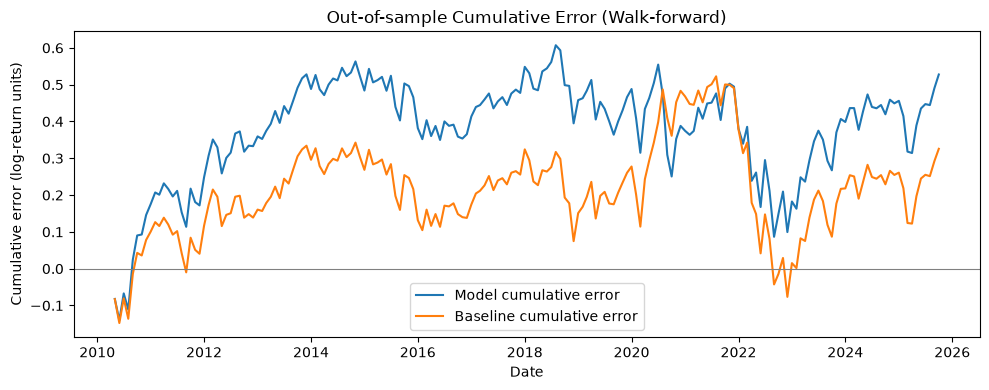

In [80]:
wf = df.copy()
LAGGED = [f"{v}_lag" for v in FEATURES]
wf[LAGGED] = wf[FEATURES].shift(1)
wf = wf.dropna()

preds, base_preds, actuals, dates = [], [], [], []

for i in range(WINDOW, len(wf)):
    train = wf.iloc[i - WINDOW:i]
    test = wf.iloc[i:i + 1]

    m = sm.OLS(train["QQQ"], sm.add_constant(train[LAGGED])).fit()

    x_te = sm.add_constant(test[LAGGED], has_constant="add")
    preds.append(m.predict(x_te).iloc[0])
    base_preds.append(train["QQQ"].mean())       # benchmark: Past 60 month average return
    actuals.append(test["QQQ"].iloc[0])
    dates.append(test.index[0])

preds = pd.Series(preds, index=dates, name="model")
base_preds = pd.Series(base_preds, index=dates, name="baseline")
actuals = pd.Series(actuals, index=dates, name="actual")

rmse_model = np.sqrt(np.mean((actuals - preds) ** 2))
rmse_base = np.sqrt(np.mean((actuals - base_preds) ** 2))
dir_model = np.mean(np.sign(actuals) == np.sign(preds))
dir_base = np.mean(np.sign(actuals) == np.sign(base_preds))
oos_r2 = 1 - np.sum((actuals - preds) ** 2) / np.sum((actuals - base_preds) ** 2)

print(f"WALK-FORWARD VALIDATION (lagged predictors, n = {len(actuals)})")
print(f"RMSE          model {rmse_model:.5f}   |   baseline {rmse_base:.5f}")
print(f"Direction acc model {dir_model:.3f}     |   baseline {dir_base:.3f}")
print(f"Out-of-sample R2    {oos_r2:+.4f}")
print("\n[Note] The model does not consistently beat the trailing-mean benchmark.")
print("       The framework is therefore explanatory, not a short-term forecasting model.")

plt.figure(figsize=(10, 4))
plt.plot(actuals.index, (actuals - preds).cumsum(), label="Model cumulative error")
plt.plot(actuals.index, (actuals - base_preds).cumsum(), label="Baseline cumulative error")
plt.axhline(0, color="grey", linewidth=0.8)
plt.title("Out-of-sample Cumulative Error (Walk-forward)")
plt.xlabel("Date")
plt.ylabel("Cumulative error (log-return units)")
plt.legend()
plt.tight_layout()
plt.show()

**RMSE: model 0.05205 vs baseline 0.05014** (lower is better, the model loses).
**Directional accuracy: model 0.575 vs baseline 0.640** (higher is better, the
model loses again).

RMSE captures magnitude accuracy, directional accuracy captures whether the sign of the return is right. Here the model loses on both, so
the conclusion is unambiguous.

**The baseline's 0.640 should be interpreted carefully.** The baseline predicted a
positive return in 100% of months, so it is effectively a rule that always says
"up". Its accuracy of 0.6398 is exactly the share of months in which QQQ actually
rose (63.98%). The model predicted a positive return 83.9% of the time, meaning it
called a decline in roughly one month in six. Those calls were mostly wrong, which
is what pulled accuracy down to 0.575. Adding macro information destroyed the
natural edge rather than improving on it.

**This study is best understood as an explanatory framework for how macroeconomic sensitivity to equity returns evolves over time, rather than as a short-term return forecasting model.**

## Limitations and Future Improvement

**1. The predictors were chosen to explain, not to forecast.**
dDGS10 and GDP_yoy describe the contemporaneous relationship well, but forecasting
requires variables that carry information ahead of the market. Lagging a yield change
by one month removes most of its content, because yield changes are themselves close
to unforecastable. Forward-filled quarterly GDP adds no new information in two of
every three months. This is a design limitation, not an implementation error, and it
is consistent with the walk-forward result.

**2. The model uses the change in yields but not the level.**
A move from 0.5% to 1.5% and a move from 3% to 5% are both a one point increase, but
they are not economically equivalent. Nasdaq (2021) finds that the level matters as
much as the direction: when yields are already high, further increases tend to hurt
equity markets, whereas from a low base rising yields have historically been
associated with positive equity returns.

This omission is directly relevant to the main finding. The sign reversal in 2022
coincided with yields rising from an unusually low base into restrictive territory,
so part of what the rolling window is capturing may be a level effect that the
specification cannot separate from the change effect.

**Extension:** add the yield level as a regressor, or include an interaction term
between level and change, and test whether the rolling reversal survives.

**3. Other extensions.**
Model P/E and EPS growth directly to separate the valuation channel from the earnings
channel, rather than inferring both from price returns. Test a longer forecast horizon,
since return predictability generally increases with horizon. Formally classify macro
regimes and test whether rate sensitivity differs systematically across them.